In [1]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

pd.set_option('display.max_columns', None)


In [2]:
DATA_PATH = "../data/customer_transactions.csv"
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
df.head()


Shape: (10000, 8)


,customer_id,invoice_id,invoice_date,purchase_amount,product_category,payment_method,customer_segment,region
0,CUST_102,INV_0,2024-01-23,71.39,Clothing,UPI,Loyal,North
1,CUST_435,INV_1,2024-02-23,56.88,Clothing,Credit Card,Returning,South
2,CUST_860,INV_2,2024-03-05,89.96,Electronics,Cash on Delivery,Loyal,East
3,CUST_270,INV_3,2024-05-19,26.58,Beauty,Cash on Delivery,New,South
4,CUST_106,INV_4,2024-01-24,283.46,Books,Credit Card,Returning,North


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  object 
 1   invoice_id        10000 non-null  object 
 2   invoice_date      10000 non-null  object 
 3   purchase_amount   10000 non-null  float64
 4   product_category  10000 non-null  object 
 5   payment_method    10000 non-null  object 
 6   customer_segment  10000 non-null  object 
 7   region            10000 non-null  object 
dtypes: float64(1), object(7)
memory usage: 625.1+ KB


In [4]:
# Missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")


Missing values per column:
No missing values found.


In [5]:
# Duplicate rows
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after dropping duplicates: {df.shape}")


Duplicate rows: 0
Shape after dropping duplicates: (10000, 8)


In [6]:
# Drop rows missing critical fields (id, amount) - adjust threshold as needed
critical_cols = ["customer_id", "invoice_id", "purchase_amount"]
before = df.shape[0]
df = df.dropna(subset=critical_cols)
print(f"Dropped {before - df.shape[0]} rows missing critical fields.")

# For remaining categorical nulls, fill with 'unknown' rather than dropping
categorical_cols = ["product_category", "payment_method", "customer_segment", "region"]
for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna("unknown")


Dropped 0 rows missing critical fields.


In [7]:
# Data types
df["invoice_date"] = pd.to_datetime(df["invoice_date"], errors="coerce")
df["purchase_amount"] = pd.to_numeric(df["purchase_amount"], errors="coerce")

# Drop any rows where coercion failed
before = df.shape[0]
df = df.dropna(subset=["invoice_date", "purchase_amount"])
print(f"Dropped {before - df.shape[0]} rows with invalid date/amount.")


Dropped 0 rows with invalid date/amount.


In [8]:
# Normalize text columns: strip whitespace, lowercase
for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

df[categorical_cols].nunique()


product_category    5
payment_method      4
customer_segment    3
region              4
dtype: int64

In [9]:
# Sanity check: negative or zero purchase amounts are almost certainly bad data
invalid_amounts = (df["purchase_amount"] <= 0).sum()
print(f"Non-positive purchase amounts: {invalid_amounts}")

df = df[df["purchase_amount"] > 0].reset_index(drop=True)

# Basic outlier check with IQR (informational only, no rows dropped here)
q1, q3 = df["purchase_amount"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
n_outliers = (df["purchase_amount"] > upper_bound).sum()
print(f"Purchase amounts above IQR upper bound ({upper_bound:.2f}): {n_outliers} "
      f"({n_outliers/len(df):.1%}) — kept, since high spenders are meaningful for CLV.")


Non-positive purchase amounts: 1
Purchase amounts above IQR upper bound (307.52): 501 (5.0%) — kept, since high spenders are meaningful for CLV.


In [10]:
print(f"Final cleaned shape: {df.shape}")
df.describe(include='all').T


Final cleaned shape: (9999, 8)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
customer_id,9999,1000,CUST_725,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
invoice_id,9999,9999,INV_0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
invoice_date,9999,NaN,NaN,NaN,2024-03-29 11:15:17.011701248,2024-01-01 00:00:00,2024-02-14 00:00:00,2024-03-28 00:00:00,2024-05-13 00:00:00,2024-06-28 00:00:00,NaN
purchase_amount,9999.0,NaN,NaN,NaN,102.221921,0.03,29.605,70.96,140.77,949.57,102.4977
product_category,9999,5,books,2096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,9999,4,debit card,2591,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_segment,9999,3,new,3360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,9999,4,north,2534,NaN,NaN,NaN,NaN,NaN,NaN,NaN


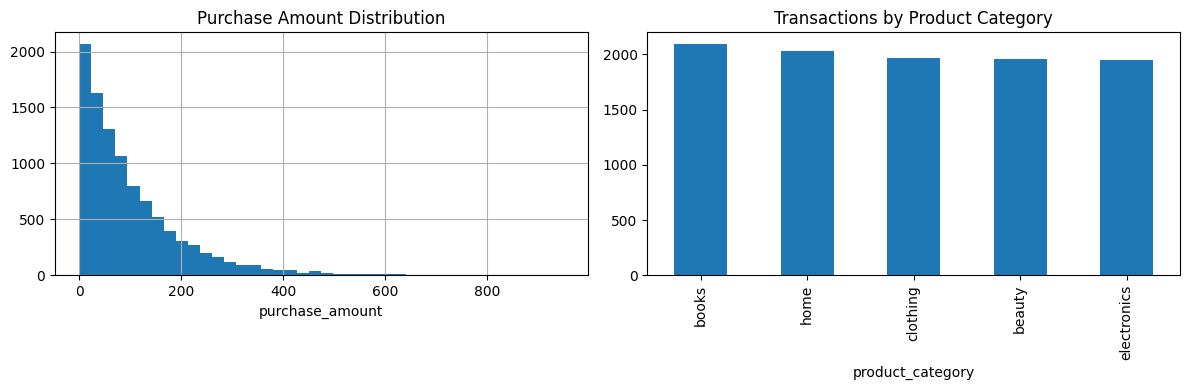

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df["purchase_amount"].hist(bins=40, ax=axes[0])
axes[0].set_title("Purchase Amount Distribution")
axes[0].set_xlabel("purchase_amount")

df["product_category"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Transactions by Product Category")

plt.tight_layout()
plt.show()


In [13]:
def add_clv_feature(data: pd.DataFrame) -> pd.DataFrame:
    """Adds 'customer_lifetime_value' as total purchase amount per customer."""
    clv = data.groupby("customer_id")["purchase_amount"].sum().reset_index()
    clv = clv.rename(columns={"purchase_amount": "customer_lifetime_value"})
    return data.merge(clv, on="customer_id", how="left")

df_fe = add_clv_feature(df)
df_fe[["customer_id", "purchase_amount", "customer_lifetime_value"]].head()


,customer_id,purchase_amount,customer_lifetime_value
0,CUST_102,71.39,1174.56
1,CUST_435,56.88,852.01
2,CUST_860,89.96,859.32
3,CUST_270,26.58,965.77
4,CUST_106,283.46,1046.54


In [14]:
df_fe["customer_lifetime_value"].describe()


count    9999.000000
mean     1135.335952
std       483.667359
min        91.220000
25%       779.640000
50%      1091.960000
75%      1420.050000
max      3131.330000
Name: customer_lifetime_value, dtype: float64

Optional extra features that are commonly useful for CLV modeling (not required by the current model, but handy if you extend it later):
- `purchase_count` — number of transactions per customer
- `avg_purchase_amount` — mean spend per transaction
- `customer_tenure_days` — days between first and last purchase


In [15]:
agg = df_fe.groupby("customer_id").agg(
    purchase_count=("invoice_id", "count"),
    avg_purchase_amount=("purchase_amount", "mean"),
    first_purchase=("invoice_date", "min"),
    last_purchase=("invoice_date", "max"),
).reset_index()
agg["customer_tenure_days"] = (agg["last_purchase"] - agg["first_purchase"]).dt.days

df_fe = df_fe.merge(
    agg[["customer_id", "purchase_count", "avg_purchase_amount", "customer_tenure_days"]],
    on="customer_id",
    how="left"
)

df_fe.head()


,customer_id,invoice_id,invoice_date,purchase_amount,product_category,payment_method,customer_segment,region,customer_lifetime_value,purchase_count,avg_purchase_amount,customer_tenure_days
0,CUST_102,INV_0,2024-01-23,71.39,clothing,upi,loyal,north,1174.56,8,146.820000,153
1,CUST_435,INV_1,2024-02-23,56.88,clothing,credit card,returning,south,852.01,12,71.000833,173
2,CUST_860,INV_2,2024-03-05,89.96,electronics,cash on delivery,loyal,east,859.32,9,95.480000,148
3,CUST_270,INV_3,2024-05-19,26.58,beauty,cash on delivery,new,south,965.77,12,80.480833,160
4,CUST_106,INV_4,2024-01-24,283.46,books,credit card,returning,north,1046.54,8,130.817500,138


## 5. Preprocessing Pipeline

Same structure as `src/preprocessor.py`:
- `purchase_amount` passed through (numeric, already clean)
- Categorical columns one-hot encoded

This is the exact transformer the Streamlit app's model expects at inference time.


In [16]:
numeric_features = ["purchase_amount"]
categorical_features = ["product_category", "payment_method", "customer_segment", "region"]

preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

X = df_fe[numeric_features + categorical_features]
X_transformed = preprocessor.fit_transform(X)

print(f"Transformed feature matrix shape: {X_transformed.shape}")


Transformed feature matrix shape: (9999, 17)


In [17]:
# Inspect the generated one-hot feature names
feature_names = (
    numeric_features
    + list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
)
print(f"Total features after encoding: {len(feature_names)}")
feature_names


Total features after encoding: 17


['purchase_amount',
 'product_category_beauty',
 'product_category_books',
 'product_category_clothing',
 'product_category_electronics',
 'product_category_home',
 'payment_method_cash on delivery',
 'payment_method_credit card',
 'payment_method_debit card',
 'payment_method_upi',
 'customer_segment_loyal',
 'customer_segment_new',
 'customer_segment_returning',
 'region_east',
 'region_north',
 'region_south',
 'region_west']

In [18]:
os.makedirs("../artifacts", exist_ok=True)

# Cleaned + feature-engineered dataset (handy for retraining or analysis)
df_fe.to_csv("../artifacts/clv_features.csv", index=False)

# Fitted preprocessor (overwrite only if you intend to retrain the model on this data too,
# since the existing model.pkl was trained against the current preprocessor.pkl)
# joblib.dump(preprocessor, "../artifacts/preprocessor.pkl")

print("Saved cleaned + feature-engineered dataset to ../artifacts/clv_features.csv")


Saved cleaned + feature-engineered dataset to ../artifacts/clv_features.csv
